# Olympic Games: 120 Years of Athletic Excellence & Medal Prediction

#### -------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_events = pd.read_csv("athlete_events.csv")
df_noc = pd.read_csv("noc_regions.csv")

In [4]:
print(f"Events Dataset Shape: {df_events.shape}")
print(f"NOC Dataset Shape: {df_noc.shape}")
print("-"*30)
print(f"Total Years: {df_events["Year"].min()} - {df_events["Year"].max()}")
print(f"Total Athletes: {df_events["ID"].nunique():,}")
print(f"Medal WINNERS: {df_events["Medal"].notna().sum():,}")

Events Dataset Shape: (271116, 15)
NOC Dataset Shape: (230, 3)
------------------------------
Total Years: 1896 - 2016
Total Athletes: 135,571
Medal WINNERS: 39,783


### ---------------------------------------------------------------------------------------------------------------------

## 2. Exploratory Data Analysis

In [5]:
print("ATHLETE EVENTS DATASET")
print("="*50)
display(df_events.head())

print("\n DATA TYPES AND MISSING VALUES")
print("="*50)
info_df = pd.DataFrame({
    "Data Type": df_events.dtypes,
    "Missing Count": df_events.isnull().sum(),
    "Missing %": (df_events.isnull().sum() / len(df_events) * 100).round(2),
})
display(info_df[info_df["Missing Count"] > 0])

ATHLETE EVENTS DATASET


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN



 DATA TYPES AND MISSING VALUES


,Data Type,Missing Count,Missing %
Age,float64,9474,3.49
Height,float64,60171,22.19
Weight,float64,62875,23.19
Medal,object,231333,85.33


## Key statistics about the dataset

In [6]:
print("KEY DATASET STATISTICS")
print("=" * 50)

total_athletes = df_events["ID"].nunique()
total_events = df_events["Event"].nunique()
total_games = df_events["Games"].nunique()
total_sports = df_events["Sport"].nunique()
total_countries = df_events["NOC"].nunique()

stats = {
    "Unique Athlete": f"{total_athletes:,}",
    "Unique Events": f"{total_events:,}",
    "Sports": f"{total_sports:,}",
    "Countrise": f"{total_countries:,}",
    "Olypmics Games": f"{total_games:,}",
    "Medal Awards": f"{df_events["Medal"].notna().sum():,}",
    "Medal Rate": f"{(df_events["Medal"].notna().sum() / len(df_events) * 100):.1f}%"
}

for key, value in stats.items():
    print(f"{key}: {value}")

KEY DATASET STATISTICS
Unique Athlete: 135,571
Unique Events: 765
Sports: 66
Countrise: 230
Olypmics Games: 51
Medal Awards: 39,783
Medal Rate: 14.7%


## Olympic Games Evolution Over Time

In [10]:
evoluation_stats = df_events.groupby("Year").agg({
    "ID": "nunique",
    "Event": "nunique",
    "NOC": "nunique",
    "Medal": lambda x: x.notna().sum()
}).rename(columns={
    "ID": "Athletes",
    "Event": "Events",
    "NOC": "Countries",
    "Medal": "Medals"
})

evoluation_stats.head()

,Athletes,Events,Countries,Medals
Year,,,,
1896,176,43,12,143
1900,1224,90,31,604
1904,650,95,15,486
1906,841,74,21,458
1908,2024,109,22,831


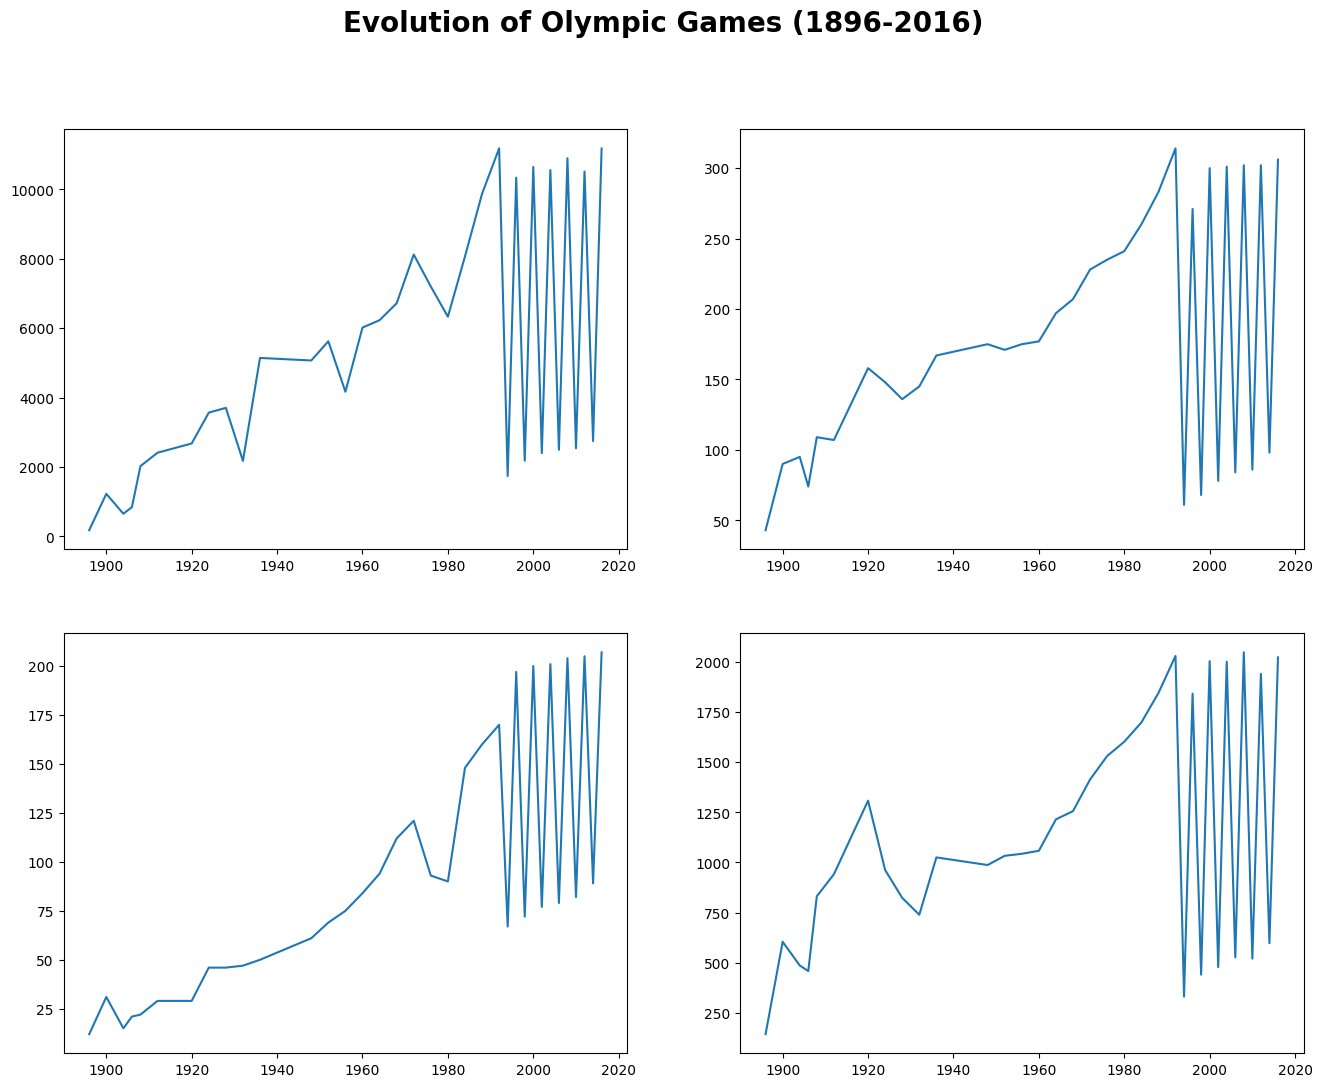

In [15]:
fig, axes = plt.subplots(2,2, figsize=(16,12))
fig.suptitle('Evolution of Olympic Games (1896-2016)', fontsize=20, fontweight='bold')

axes[0,0].plot(evoluation_stats.index, evoluation_stats["Athletes"])
axes[0,0].set

axes[0,1].plot(evoluation_stats.index, evoluation_stats["Events"])

axes[1,0].plot(evoluation_stats.index, evoluation_stats["Countries"])

axes[1,1].plot(evoluation_stats.index, evoluation_stats["Medals"])